# Notebook Overview
In this codebook we go over the Mushroom dataset; in particular we are interested in predicting whether
a given mushroom is poisonous or edible. Below, we will briefly explore the data as well as the given text, 
we must modify the data by extracting column names from the text, split the data up between x and y, and 
then again split the data up between training and testing sets, and finally we will have to actually go
train and test the data so we can determine the optimal model for our purposes. 

In [2]:
import numpy as np
import pandas as pd
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns
import keras

In [3]:
df = pd.read_csv("agaricus-lepiota.csv", header = None)

In [4]:
# let's start off with some basic data exploration. we need to keep in mind that our goal is to predict the p column (p for poison)
df

,0,1,2,3,4,5,6,7,8,9,...,13,14,15,16,17,18,19,20,21,22
0,p,x,s,n,t,p,f,c,n,k,...,s,w,w,p,w,o,p,k,s,u
1,e,x,s,y,t,a,f,c,b,k,...,s,w,w,p,w,o,p,n,n,g
2,e,b,s,w,t,l,f,c,b,n,...,s,w,w,p,w,o,p,n,n,m
3,p,x,y,w,t,p,f,c,n,n,...,s,w,w,p,w,o,p,k,s,u
4,e,x,s,g,f,n,f,w,b,k,...,s,w,w,p,w,o,e,n,a,g
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8119,e,k,s,n,f,n,a,c,b,y,...,s,o,o,p,o,o,p,b,c,l
8120,e,x,s,n,f,n,a,c,b,y,...,s,o,o,p,n,o,p,b,v,l
8121,e,f,s,n,f,n,a,c,b,n,...,s,o,o,p,o,o,p,b,c,l
8122,p,k,y,n,f,y,f,c,n,b,...,k,w,w,p,w,o,e,w,v,l


In [5]:
# great news! no null values. also these are all object data-types, 22x8123, 23 columns. 
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8124 entries, 0 to 8123
Data columns (total 23 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   0       8124 non-null   object
 1   1       8124 non-null   object
 2   2       8124 non-null   object
 3   3       8124 non-null   object
 4   4       8124 non-null   object
 5   5       8124 non-null   object
 6   6       8124 non-null   object
 7   7       8124 non-null   object
 8   8       8124 non-null   object
 9   9       8124 non-null   object
 10  10      8124 non-null   object
 11  11      8124 non-null   object
 12  12      8124 non-null   object
 13  13      8124 non-null   object
 14  14      8124 non-null   object
 15  15      8124 non-null   object
 16  16      8124 non-null   object
 17  17      8124 non-null   object
 18  18      8124 non-null   object
 19  19      8124 non-null   object
 20  20      8124 non-null   object
 21  21      8124 non-null   object
 22  22      8124 non-null   

In [6]:
with open('agaricus-lepiota.names', 'r') as file:
    lines = file.readlines()

lines

['1. Title: Mushroom Database\n',
 '\n',
 '2. Sources: \n',
 '    (a) Mushroom records drawn from The Audubon Society Field Guide to North\n',
 '        American Mushrooms (1981). G. H. Lincoff (Pres.), New York: Alfred\n',
 '        A. Knopf\n',
 '    (b) Donor: Jeff Schlimmer (Jeffrey.Schlimmer@a.gp.cs.cmu.edu)\n',
 '    (c) Date: 27 April 1987\n',
 '\n',
 '3. Past Usage:\n',
 '    1. Schlimmer,J.S. (1987). Concept Acquisition Through Representational\n',
 '       Adjustment (Technical Report 87-19).  Doctoral disseration, Department\n',
 '       of Information and Computer Science, University of California, Irvine.\n',
 '       --- STAGGER: asymptoted to 95% classification accuracy after reviewing\n',
 '           1000 instances.\n',
 '    2. Iba,W., Wogulis,J., & Langley,P. (1988).  Trading off Simplicity\n',
 '       and Coverage in Incremental Concept Learning. In Proceedings of \n',
 '       the 5th International Conference on Machine Learning, 73-79.\n',
 '       Ann Arbor, Mic

In [7]:
column_names = [
    'class', 'cap-shape', 'cap-surface', 'cap-color', 'bruises?', 'odor', 'gill-attachment', 'gill-spacing', 'gill-size',
    'gill-color', 'stalk-shape', 'stalk-root', 'stalk-surface-above-ring', 'stalk-surface-below-ring', 
    'stalk-color-above-ring', 'stalk-color-below-ring', 'veil-type', 'veil-color', 'ring-number', 'ring-type', 
    'spore-print-color', 'population', 'habitat'
]

df.columns = column_names

In [8]:
# column names are now corrected!
df

,class,cap-shape,cap-surface,cap-color,bruises?,odor,gill-attachment,gill-spacing,gill-size,gill-color,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
0,p,x,s,n,t,p,f,c,n,k,...,s,w,w,p,w,o,p,k,s,u
1,e,x,s,y,t,a,f,c,b,k,...,s,w,w,p,w,o,p,n,n,g
2,e,b,s,w,t,l,f,c,b,n,...,s,w,w,p,w,o,p,n,n,m
3,p,x,y,w,t,p,f,c,n,n,...,s,w,w,p,w,o,p,k,s,u
4,e,x,s,g,f,n,f,w,b,k,...,s,w,w,p,w,o,e,n,a,g
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8119,e,k,s,n,f,n,a,c,b,y,...,s,o,o,p,o,o,p,b,c,l
8120,e,x,s,n,f,n,a,c,b,y,...,s,o,o,p,n,o,p,b,v,l
8121,e,f,s,n,f,n,a,c,b,n,...,s,o,o,p,o,o,p,b,c,l
8122,p,k,y,n,f,y,f,c,n,b,...,k,w,w,p,w,o,e,w,v,l


In [9]:
X = df.drop('class', axis = 1)
y = df['class']

In [10]:
from sklearn.preprocessing import OneHotEncoder, LabelEncoder
from sklearn.model_selection import train_test_split

# Encoding the target variable
y_encoded = LabelEncoder().fit_transform(y)

# ran into error splitting the data before before encoding y regarding matching data, so attempting to change order
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size = .2, stratify = y_encoded)

# categorical data must be transformed in order to be comparable. 
encoder = OneHotEncoder(handle_unknown = 'ignore', sparse_output = False)
X_train_cat_1hot = encoder.fit_transform(X_train)
X_test_1hot = encoder.transform(X_test)

# lets make sure everything came out correctly
print(np.unique(X_train_cat_1hot))
print(np.unique(y_encoded))

[0. 1.]
[0 1]


In [11]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
# refer to pg 299

model = Sequential()

# ran into issue where input_dim was not matching the no. of features post OneHotEncode was run.
num_features = X_train_cat_1hot.shape[1] 

# 2 hidden layers
model.add(Dense(300, activation = 'relu', input_dim = num_features))
model.add(Dense(100, activation = 'relu'))

#output layer
model.add(Dense(1, activation = 'sigmoid'))

# compiling model
model.compile(optimizer = 'adam', loss = 'binary_crossentropy', metrics = ['accuracy'])
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 300)               35100     
                                                                 
 dense_1 (Dense)             (None, 100)               30100     
                                                                 
 dense_2 (Dense)             (None, 1)                 101       
                                                                 
Total params: 65,301
Trainable params: 65,301
Non-trainable params: 0
_________________________________________________________________


2025-08-21 20:12:31.452248: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [12]:
from sklearn.linear_model import LogisticRegression
import time

start_time = time.time()

log_reg = LogisticRegression()
log_reg.fit(X_train_cat_1hot, y_train)

end_time = time.time()

# stuggled to get %%time command to work
time_elapsed = end_time - start_time
time_elapsed

0.07833981513977051

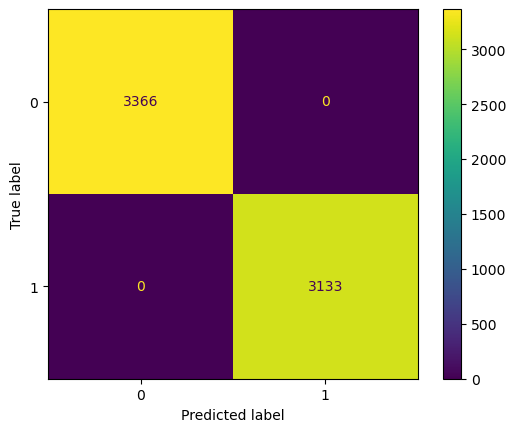

In [13]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.svm import SVC

clf = SVC()
clf.fit(X_train_cat_1hot, y_train)
predictions = clf.predict(X_train_cat_1hot)
cm = confusion_matrix(y_train, predictions, labels = clf.classes_)

disp = ConfusionMatrixDisplay(
    confusion_matrix = cm, 
    display_labels = log_reg.classes_
)

# a perfect classifier; no false positives nor false negatives.
disp.plot()
plt.show()

accuracy: 1.0000
recall: 1.0000
F1: 1.0000
precision: 1.0000


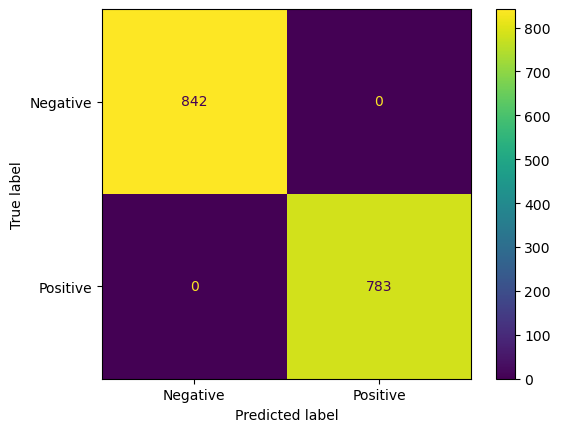

In [14]:
from sklearn.metrics import accuracy_score, recall_score, f1_score, precision_score 
from sklearn.metrics import ConfusionMatrixDisplay as cmd
import seaborn as sns

sns.reset_orig()
y_predicted = log_reg.predict(X_test_1hot)

accuracy = accuracy_score(y_test, y_predicted)
recall = recall_score(y_test, y_predicted)
f1 = f1_score(y_test, y_predicted)
precision = precision_score(y_test, y_predicted)

print(f"accuracy: {accuracy:.4f}")
print(f"recall: {recall:.4f}")
print(f"F1: {f1:.4f}")
print(f"precision: {precision:.4f}")

labels = ['Negative', 'Positive']
cmd.from_predictions(y_test, y_predicted, display_labels = labels)

In [15]:
from sklearn.decomposition import PCA

pca = PCA(n_components = 0.95) 
X_train_pca = pca.fit_transform(X_train_cat_1hot) 
X_test_pca = pca.transform(X_test_1hot)

print(X_train_pca.shape)

(6499, 40)


In [16]:
# new neural network
start_time = time.time()

#log_reg = LogisticRegression()
pca.fit(X_train_pca, y_train)

end_time = time.time()

# PCA is decisively faster
time_elapsed = end_time - start_time
time_elapsed

0.017882108688354492

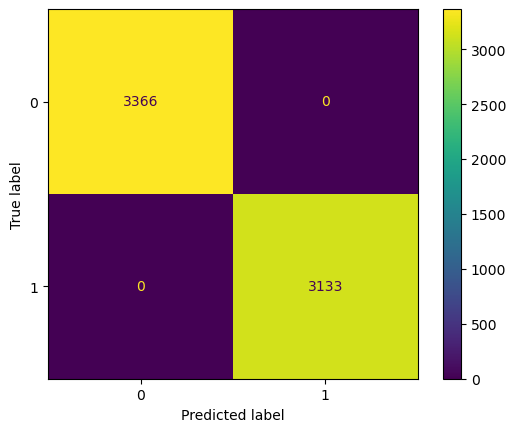

In [17]:
clf = SVC()
clf.fit(X_train_pca, y_train)
predictions = clf.predict(X_train_pca)
cm = confusion_matrix(y_train, predictions, labels = clf.classes_)

disp = ConfusionMatrixDisplay(
    confusion_matrix = cm, 
    display_labels = log_reg.classes_
)

# a perfect classifier once again.
disp.plot()
plt.show()

accuracy: 1.0000
recall: 1.0000
F1: 1.0000
precision: 1.0000


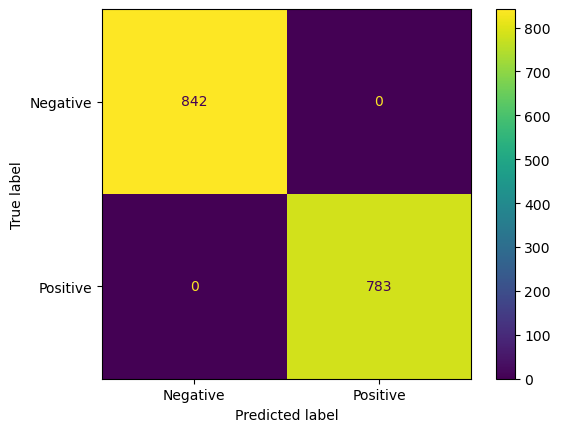

In [18]:
sns.reset_orig()
y_predicted = log_reg.predict(X_test_1hot)

accuracy = accuracy_score(y_test, y_predicted)
recall = recall_score(y_test, y_predicted)
f1 = f1_score(y_test, y_predicted)
precision = precision_score(y_test, y_predicted)

print(f"accuracy: {accuracy:.4f}")
print(f"recall: {recall:.4f}")
print(f"F1: {f1:.4f}")
print(f"precision: {precision:.4f}")

labels = ['Negative', 'Positive']
cmd.from_predictions(y_test, y_predicted, display_labels = labels)

### 10a
Q: How many features does the data have after the One-Hot Encoding? How does this compare to the number of features that the data had before the encoding?

There are 116 features post OneHotEncoding, rather than 22. This is due to OneHot's binary nature 
being multiplied by various categories. 

### 10b
Q: What should the units parameter of the output layer in the network be and why?

1 unit should be the parameter because the question asks for a binary result– 
either the mushroom is poisonous, or it is edible– and there is no in between result.

### 10c
Q: How many connections does your neural network contain?

I have 65,301 in my network; (116 * 300 + 300) + (300 * 100 + 100) + (100 * 1 + 1) = 65,301

### 10d
My PCA has 41 features; this is demonsrated by X_train_pca.shape: (6499, 41)

### 10e
Q: How many features does the training data contain after dimensionality reduction? How does this compare with the encoded data? 

The input_dim of the sequential neural network is set to 116 becuase it must match the total number of features
that are being fed into the neural network. Although originally there were 22 features– OneHotEncoding 
multiplied it over 5 times that to 116 (as explained earlier), in order to account for variations of each 
feature that cannot be neglected. 


### 10f
Q: Compare the training time of the original neural network with the training time of the PCA neural network. Are the results what you expected? 

The fact that PCA was quicker than the sequential network is well known and to be expected since PCA 
condenses the features where possible. PCA condensing/streamlining the number of features from 116 to
41 is a major development. 